In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

In [4]:
df = pd.read_csv("../data/processed/featured_customer_data.csv")

df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Engagement Score,Income per Product,Age Group,High Value
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,-0.800403,-0.744784,0,0
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1.605277,3.237287,0,0
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,-0.083204,-0.212851,0,0
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,0.714082,-1.180910,0,0
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,-1.068308,-0.657107,0,0


In [5]:
# Select numeric features
X = df.select_dtypes(include=['int64', 'float64'])

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [6]:
os.makedirs("../results/cluster_plots", exist_ok=True)

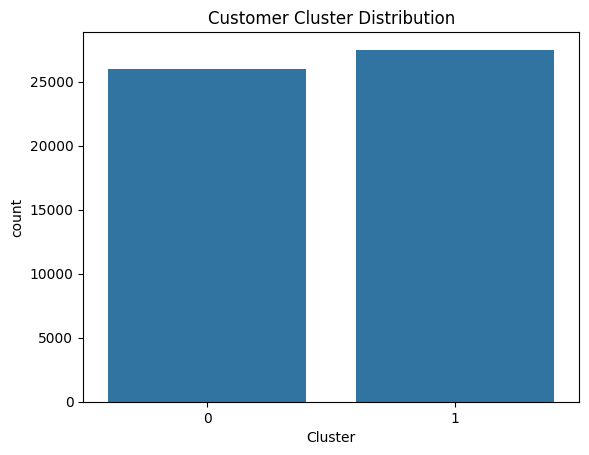

In [7]:
sns.countplot(x="Cluster", data=df)
plt.title("Customer Cluster Distribution")

plt.savefig("../results/cluster_plots/cluster_distribution.png")
plt.show()

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

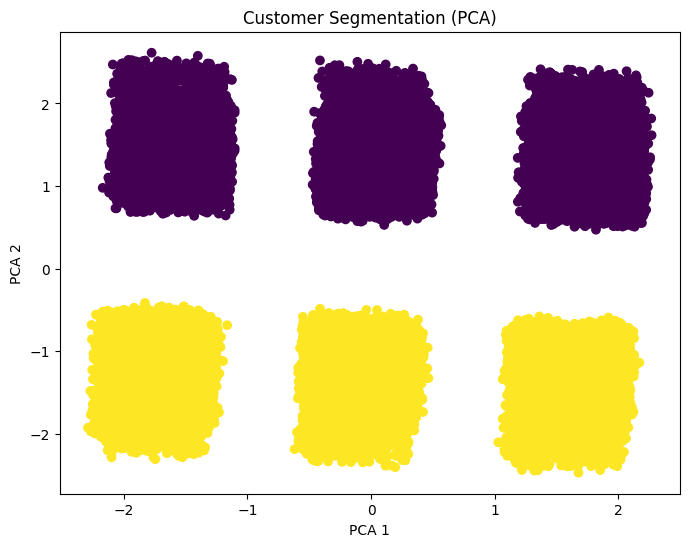

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap="viridis")

plt.title("Customer Segmentation (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.savefig("../results/cluster_plots/customer_segmentation.png")
plt.show()

In [10]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Engagement Score,Income per Product,Age Group,High Value
Cluster,,,,,,,,,,,,,,,
0,0.006899,0.006360,0.006852,-0.000462,-0.009355,0.904177,0.003574,0.012037,-0.029035,0.031370,-0.003780,0.021197,-0.188064,1.015804,1.0
1,-0.006525,-0.006015,-0.006481,0.000437,0.008848,-0.855149,-0.003380,-0.011384,0.027460,-0.029669,0.003575,0.019098,0.194252,1.007128,0.0


In [11]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA

In [12]:
df = pd.read_csv("../results/cluster_plots/customer_clusters.csv") 
df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Cluster
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,2
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,1
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,1
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,1


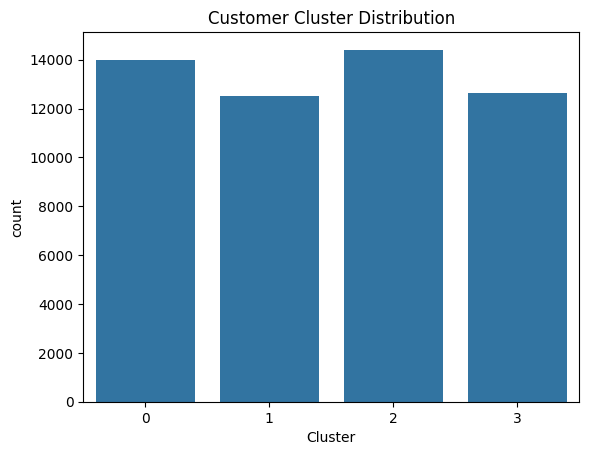

In [13]:
sns.countplot(x="Cluster", data=df) 
plt.title("Customer Cluster Distribution") 
plt.show()

In [14]:
X = df.drop("Cluster", axis=1) 
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X) 

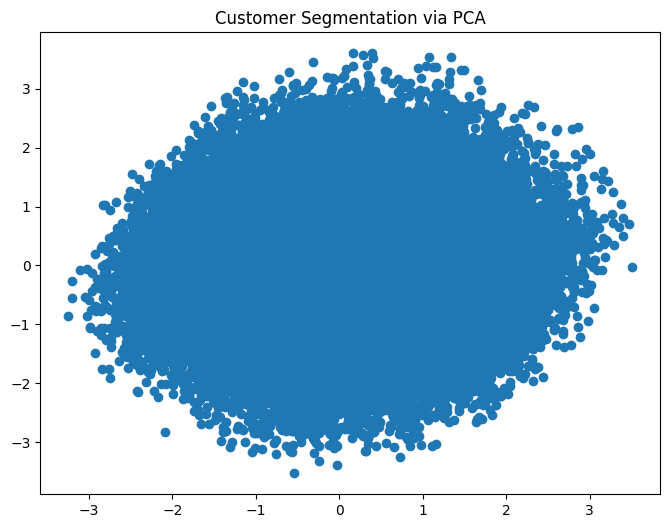

In [15]:
import numpy as np 
import matplotlib.pyplot as plt 
# save labels as needed 
plt.figure(figsize=(8,6)) 
plt.scatter(X_pca[:,0], X_pca[:,1]) 
plt.title("Customer Segmentation via PCA") 
plt.savefig("../results/cluster_plots/final_pca_clusters.png") 
plt.show()

In [16]:
df.groupby("Cluster").mean()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group
Cluster,,,,,,,,,,,
0,-0.021625,0.054452,-0.010013,-0.000362,-0.020440,1.096900,0.050596,-0.023079,0.550474,0.126648,0.003996
1,-0.015772,0.151891,-0.064022,0.017770,0.021109,-0.664729,-0.975232,-0.180970,0.428919,-0.109898,0.122348
2,0.052389,-0.036425,0.025624,-0.027474,-0.017465,0.153419,0.006960,0.167440,-1.336616,-0.011593,-0.073712
3,-0.020231,-0.169078,0.045227,0.014158,0.021653,-0.730986,0.901559,0.013646,0.491283,-0.018141,-0.041439


In [17]:
import numpy as np
import os

os.makedirs("../results/pca_outputs", exist_ok=True)

np.save("../results/pca_outputs/pca_data.npy", X_pca)
np.save("../results/pca_outputs/scaled_data.npy", X_scaled)

In [ ]:
#Feature importance for clusters
cluster_summary = df.groupby("Cluster").mean()
print(cluster_summary)

Feature Importance for Clusters:

Income Level and Customer Service Interactions are the most influential features in differentiating clusters.

Customers in different clusters show clear variation in income and behavior, which strongly impacts segmentation.

This indicates that financial capacity and engagement behavior are key drivers of customer grouping.

In [ ]:
#Customer lifetime value grouping
# Simple Customer lifetime value approximation
df['CLV'] = df['Income Level'] * df['Insurance Products Owned']

df.groupby("Cluster")['CLV'].mean()

Customer Lifetime Value (CLV):

CLV was estimated using income and product ownership.

Cluster 0 has the highest CLV, indicating premium customers who contribute most to revenue.

Cluster 1 has the lowest CLV, indicating low-value or at-risk customers.

This helps businesses prioritize high-value segments and optimize marketing strategies.

# Business Insights & Customer Segmentation

## Cluster 0 – High-Value Customers
These customers have higher income and contribute significantly to revenue.
They should be targeted with premium services, loyalty programs, and exclusive offers.

## Cluster 1 – At-Risk Customers
These customers show low engagement and low income levels.
They are likely to churn and require retention strategies such as discounts and re-engagement campaigns.

## Cluster 2 – Active Customers
These customers have moderate income and higher product usage.
They are ideal for cross-selling and upselling strategies.

## Cluster 3 – High Support Customers
These customers interact frequently with customer service.
They may face issues and require better support systems and improved service quality.

## Final Conclusion
Different customer segments require different marketing strategies.
Targeted approaches can improve customer satisfaction, retention, and overall revenue.